In [31]:
import pandas as pd
from pathlib import Path

ROOT = Path.cwd().parent
prices = pd.read_csv(ROOT / "data" / "clean_data.csv")
signals = pd.read_csv(ROOT / "data" / "signals_strategy_1.csv")

In [32]:
df = prices.merge(
    signals,
    on="Date",
    how="inner"
)
print(df.head())

   Unnamed: 0        Date        Close         High          Low         Open  \
0           1  2010-01-05  5277.899902  5288.350098  5242.399902  5277.149902   
1           2  2010-01-06  5281.799805  5310.850098  5260.049805  5278.149902   
2           3  2010-01-07  5263.100098  5302.549805  5244.750000  5281.799805   
3           4  2010-01-08  5244.750000  5276.750000  5234.700195  5264.250000   
4           5  2010-01-11  5249.399902  5287.200195  5227.799805  5263.799805   

   Volume       State_0   State_1        State_2  State_3        State_4  \
0       0  1.952660e-19  1.000000  1.856756e-110      0.0  6.670687e-102   
1       0  1.898562e-02  0.938718   4.202498e-02      0.0   2.714185e-04   
2       0  1.185316e-03  0.901994   9.648806e-02      0.0   3.324230e-04   
3       0  1.144737e-02  0.769153   2.190192e-01      0.0   3.804683e-04   
4       0  3.967511e-03  0.969593   2.469168e-02      0.0   1.747485e-03   

   Target_Position  Trade_Size  
0         0.750000    0

In [33]:
df["Return"] = df["Close"].pct_change()

print(df[["Date","Close","Return"]].head(10))

         Date        Close    Return
0  2010-01-05  5277.899902       NaN
1  2010-01-06  5281.799805  0.000739
2  2010-01-07  5263.100098 -0.003540
3  2010-01-08  5244.750000 -0.003487
4  2010-01-11  5249.399902  0.000887
5  2010-01-12  5210.399902 -0.007429
6  2010-01-13  5233.950195  0.004520
7  2010-01-14  5259.899902  0.004958
8  2010-01-15  5252.200195 -0.001464
9  2010-01-18  5274.850098  0.004312


In [34]:
df["Strategy_Return"] = (
    df["Target_Position"].shift(1)
    * df["Return"]
)

df["Strategy_Return"] = (
    df["Strategy_Return"]
    .fillna(0)
)

print(df[["Date","Return","Target_Position","Strategy_Return"]].head(10))

         Date    Return  Target_Position  Strategy_Return
0  2010-01-05       NaN         0.750000         0.000000
1  2010-01-06  0.000739         0.723133         0.000554
2  2010-01-07 -0.003540         0.677814        -0.002560
3  2010-01-08 -0.003487         0.588464        -0.002363
4  2010-01-11  0.000887         0.731861         0.000522
5  2010-01-12 -0.007429         0.100921        -0.005437
6  2010-01-13  0.004520         0.749785         0.000456
7  2010-01-14  0.004958         0.948745         0.003717
8  2010-01-15 -0.001464         0.714152        -0.001389
9  2010-01-18  0.004312         0.750690         0.003080


In [35]:
df["Equity"] = (
    1 + df["Strategy_Return"]
).cumprod()

print(
    df[["Date","Equity"]]
    .head(10)
)

         Date    Equity
0  2010-01-05  1.000000
1  2010-01-06  1.000554
2  2010-01-07  0.997993
3  2010-01-08  0.995634
4  2010-01-11  0.996154
5  2010-01-12  0.990737
6  2010-01-13  0.991189
7  2010-01-14  0.994874
8  2010-01-15  0.993492
9  2010-01-18  0.996552


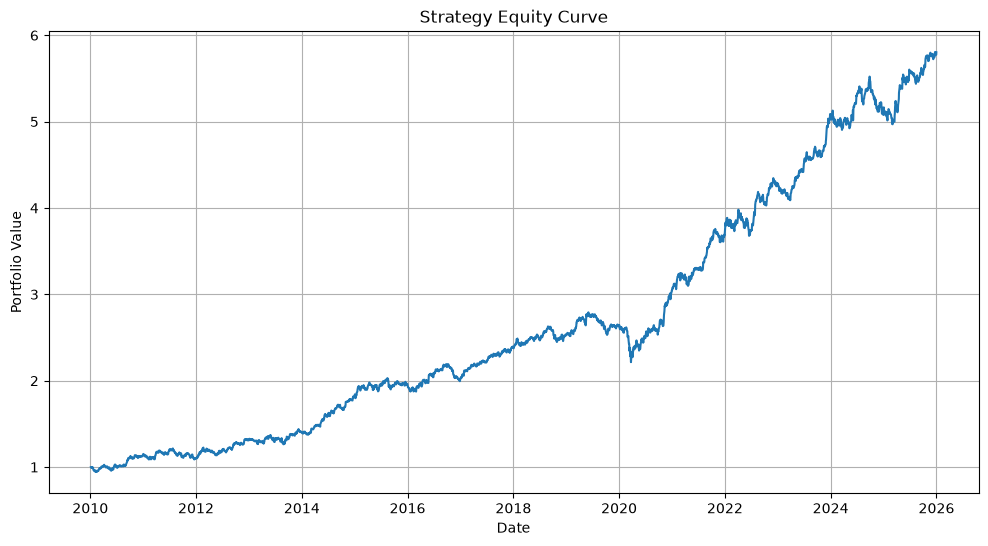

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

df["Date"] = pd.to_datetime(df["Date"])

plt.plot(
    df["Date"],
    df["Equity"]
)

plt.title("Strategy Equity Curve")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")

plt.grid(True)

plt.show()

In [37]:
years = (
    (df["Date"].iloc[-1] - df["Date"].iloc[0])
    .days
    / 365.25
)

final_equity = df["Equity"].iloc[-1]

cagr = (
    final_equity ** (1 / years)
    - 1
)

print(f"CAGR: {cagr:.2%}")

CAGR: 11.63%


In [38]:
sharpe = (
    df["Strategy_Return"].mean()
    /
    df["Strategy_Return"].std()
) * (252 ** 0.5)

print(f"Sharpe Ratio: {sharpe:.2f}")

Sharpe Ratio: 1.26


In [39]:
df["Rolling_Max"] = (
    df["Equity"]
    .cummax()
)

df["Drawdown"] = (
    df["Equity"]
    /
    df["Rolling_Max"]
    - 1
)

max_drawdown = (
    df["Drawdown"]
    .min()
)

print(
    f"Max Drawdown: {max_drawdown:.2%}"
)

Max Drawdown: -20.66%


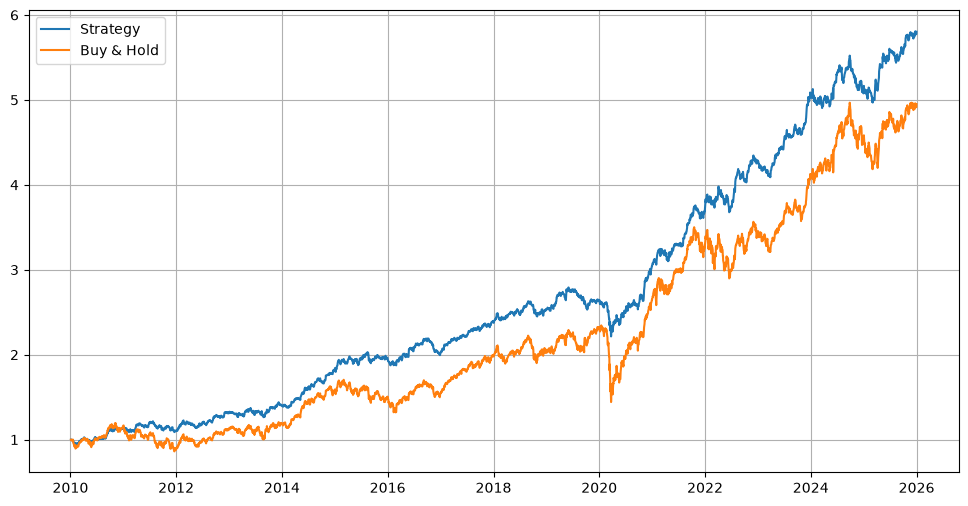

In [40]:
df["Market_Equity"] = (
    1 + df["Return"].fillna(0)
).cumprod()

plt.figure(figsize=(12,6))

plt.plot(df["Date"], df["Equity"], label="Strategy")
plt.plot(df["Date"], df["Market_Equity"], label="Buy & Hold")

plt.legend()
plt.grid(True)
plt.show()